In [1]:
import pandas as pd
import os
import requests
import json

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

In [3]:
from preprocessing_utils import preprocess_NVD_data

In [4]:
data_path = 'data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

# EPSS data

Download the EPSS data from https://www.first.org/epss/data_stats into `data` folder

### <font color='blue'><b><i>TODO</i></b></font>:
- in the following cell, replace `epss_scores-2025-09-30.csv.gz` with the correct updated file (`epss_scores-2025-10-01.csv.gz`)

In [5]:
epss_current = pd.read_csv(os.path.join(data_path, 'epss_scores-2025-10-01.csv.gz'), compression='gzip', header=1)
epss_current # a Python statement with a variable name at the end of a cell will display its contents below


,cve,epss,percentile
0,CVE-1999-0001,0.01141,0.77780
1,CVE-1999-0002,0.10742,0.93087
2,CVE-1999-0003,0.90362,0.99589
3,CVE-1999-0004,0.03215,0.86596
4,CVE-1999-0005,0.25334,0.96035
...,...,...,...
296328,CVE-2025-9994,0.00060,0.19138
296329,CVE-2025-9996,0.00179,0.40027
296330,CVE-2025-9997,0.00182,0.40386
296331,CVE-2025-9998,0.00023,0.04753


# NVD data

In [6]:
base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
date_start_NVD = '2025-09-01T00:00:00.000Z' # Do NOT change these dates
date_end_NVD   = '2025-10-01T00:00:00.000Z' # Do NOT change these dates
start_index = 0
results_per_page = 1000
total_results = 1 

all_cves = []

# If the raw NVD response was already downloaded, reload it so the notebook can be
# re-run without querying the API again. Delete data/nvd_cves.json to force a fresh pull.
_saved = os.path.join(data_path, "nvd_cves.json")
if os.path.exists(_saved):
    with open(_saved, "r", encoding="utf-8") as f:
        all_cves = json.load(f)
    print(f"Loaded {len(all_cves)} CVEs from {_saved}")
else:
    while start_index < total_results:
        params = {
            "pubStartDate": date_start_NVD,
            "pubEndDate": date_end_NVD,
            "resultsPerPage": results_per_page,
            "startIndex": start_index,
            "noRejected": ""
        }
        response = requests.get(base_url, params=params, timeout=6)
        if response.status_code != 200:
            print("Error:", response.status_code)
            break
        data = response.json()
        total_results = data.get("totalResults", 0)
        all_cves.extend(data.get("vulnerabilities", []))
        start_index += results_per_page
        print(start_index)


Loaded 4320 CVEs from data/nvd_cves.json


In [7]:
# normalize and preprocess data
df = pd.json_normalize(all_cves, record_path=None, sep='.', max_level=None)
df = preprocess_NVD_data(df)

# remove vulnerabilities marked as "reject" or "reserved"
df = df[(df['cve.vulnStatus']!='Reserved') & (df['cve.vulnStatus']!='Reject')]

# merge NVD and EPSS data
df = df.merge(epss_current, left_on="cve.id", right_on="cve", how="left")

In [8]:
# save nvd data
with open(os.path.join(data_path, "nvd_cves.json"), "w", encoding="utf-8") as f:
    json.dump(all_cves, f, indent=2)
    
# save the final dataframe
df.to_csv(os.path.join(data_path, "vuln_2025_09.csv"))

# Exploratory Data Analysis

- display some examples (e.g., the first two CVE records)

In [9]:
df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2026-06-17 10:09:40.847000,2026-06-17 10:09:40.990000
cve.vulnStatus,Analyzed,Analyzed
cve.affected,"[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [..."
cve.metrics.ssvcV203,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN


- show a bar plot with the daily volume of published CVEs

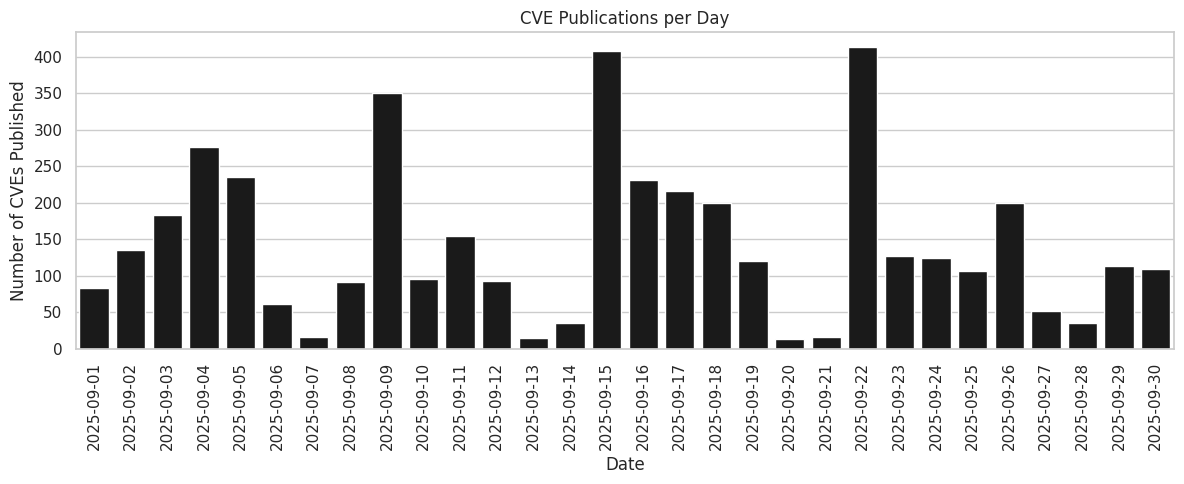

In [10]:
published_counts = df["cve.published"].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=published_counts.index, y=published_counts.values, color="k" )
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Number of CVEs Published")
plt.title("CVE Publications per Day")
plt.tight_layout()
plt.show()

In [11]:
df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2026-06-17 10:09:40.847000,2026-06-17 10:09:40.990000
cve.vulnStatus,Analyzed,Analyzed
cve.affected,"[{'source': 'cna@vuldb.com', 'affectedData': [...","[{'source': 'cna@vuldb.com', 'affectedData': [..."
cve.metrics.ssvcV203,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...,[{'source': '134c704f-9b21-4f2e-91b3-4a467353b...
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN


- print the description of the last ten published vulnerabilities

In [12]:
for idx, x in enumerate(df.sort_values('cve.published', ascending=False)[:10].iterrows()):
    print('-'*100)
    print(x[1]['cve.id'], x[1]['cve.published'])
    print(x[1].description)


----------------------------------------------------------------------------------------------------
CVE-2025-61792 2025-09-30 23:15:29.700000
Quadient DS-700 iQ devices through 2025-09-30 might have a race condition during the quick clicking of (in order) the Question Mark button, the Help Button, the About button, and the Help Button, leading to a transition out of kiosk mode into local administrative access. NOTE: the reporter indicates that the "behavior was observed sporadically" during "limited time on the client site," making it not "possible to gain more information about the specific kiosk mode crashing issue," and the only conclusion was "there appears to be some form of race condition." Accordingly, there can be doubt that a reproducible cybersecurity vulnerability was identified; sporadic software crashes can also be caused by a hardware fault on a single device (for example, transient RAM errors). The reporter also describes a variety of other issues, including initial acc

### <font color='blue'><b><i>TODO</i></b>: produce plots or tables to address the folowing points</font>
- what is the percentage of CVEs which received a CVSS score?
- report descriptive statistics of CVSS the CVSS base score and/or show its distribution
- report descriptive statistics of EPSS and/or show its distribution
- produce a scatter plot showing CVSS vs EPSS
- <b>be creative</b>!
    - How many vulnerabilities are published on CISA KEV? 
    - What are the the 20 most frequent vendors? (vendor name can be extracted from the `vulnerable_cpes` field).
    - What are the 20 most frequent CWEs?
    - Anaything else you see fit!

<font color='blue'>Use text cells to discuss the outcome after each point</font>

**What percentage of CVEs received a CVSS score?**

In [13]:
n_total = len(df)
n_cvss = df['cvss_baseScore'].notna().sum()
print(f"{n_cvss} of {n_total} CVEs have a CVSS base score ({100*n_cvss/n_total:.1f}%)")

4160 of 4320 CVEs have a CVSS base score (96.3%)


About 96% of the September CVEs already have a CVSS score, so we can use CVSS as a feature. The rest are mostly very recent entries still awaiting analysis.

**CVSS base score: descriptive statistics and distribution.**

count    4160.000000
mean        6.770986
std         1.715107
min         2.200000
25%         5.500000
50%         6.500000
75%         7.800000
max        10.000000
Name: cvss_baseScore, dtype: float64

cvss_baseSeverity
MEDIUM      2169
HIGH        1365
CRITICAL     508
LOW          118
Name: count, dtype: int64


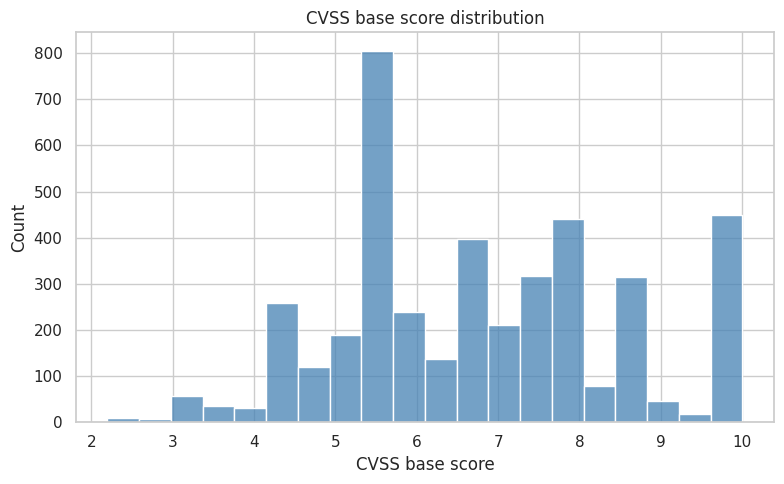

In [14]:
print(df['cvss_baseScore'].describe())
print()
print(df['cvss_baseSeverity'].value_counts())

plt.figure(figsize=(8,5))
sns.histplot(df['cvss_baseScore'].dropna(), bins=20, color="steelblue")
plt.title("CVSS base score distribution")
plt.xlabel("CVSS base score")
plt.tight_layout()
plt.show()

The scores are centred in the medium/high range (median 6.5). MEDIUM is the most common severity, but there are still many HIGH and CRITICAL CVEs to choose from.

**EPSS: descriptive statistics and distribution.**

count    4320.000000
mean        0.001477
std         0.017289
min         0.000020
25%         0.000240
50%         0.000320
75%         0.000470
max         0.810640
Name: epss, dtype: float64

CVEs with EPSS < 1%: 4262


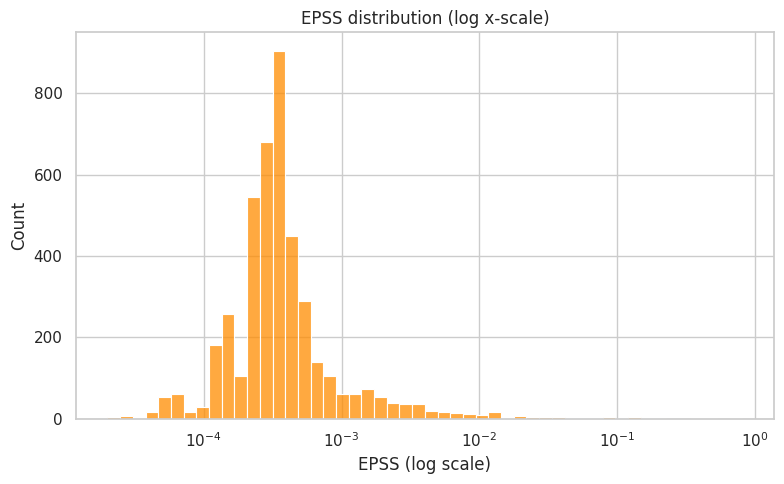

In [15]:
print(df['epss'].describe())
print()
print("CVEs with EPSS < 1%:", (df['epss'] < 0.01).sum())

plt.figure(figsize=(8,5))
sns.histplot(df['epss'], bins=50, log_scale=(True, False), color="darkorange")
plt.title("EPSS distribution (log x-scale)")
plt.xlabel("EPSS (log scale)")
plt.tight_layout()
plt.show()

EPSS is very skewed towards zero: the median is about 0.0003 and almost all CVEs (~99%) are below the 1% threshold. So the low-EPSS pool for selection is basically the whole dataset.

**CVSS vs EPSS.**

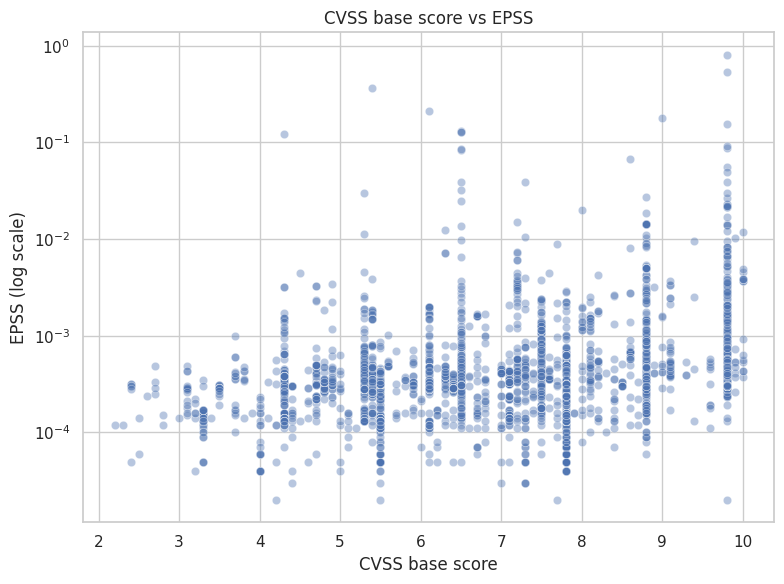

In [16]:
plot_df = df.dropna(subset=['cvss_baseScore','epss'])
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df, x='cvss_baseScore', y='epss', alpha=0.4)
plt.yscale('log')
plt.title("CVSS base score vs EPSS")
plt.xlabel("CVSS base score")
plt.ylabel("EPSS (log scale)")
plt.tight_layout()
plt.show()

There is no strong relationship between CVSS and current EPSS: plenty of high-CVSS vulnerabilities still have a very low EPSS. These high-severity, low-EPSS CVEs are the ones with the most room to increase, which is what we look for in the selection.

# CVE selection


### <font color='blue'><b><i>TODO</i></b>
- Filter the CVEs with low EPSS (<1%)
- Select candidate CVEs
    - From the resulting subset, select 10 CVEs that you think will reach high EPSS by the end of the course.
    - Clearly describe the criteria you used for selection (e.g., high CVSS, popular software, CWE, popular vendor, number of references, keyword in description, manual inspection, random sampling, security blogs).
- Share the selected CVE ids with the instructor (by two weeks). Use the code cell below to produce the csv file to submit.
- Track the EPSS of your CVEs over time


**Selection criteria.**

EPSS rises when a vulnerability starts getting exploited, which usually needs a working, easy-to-reach exploit. So from the low-EPSS pool I keep the CVEs that are the easiest and most attractive to exploit, and pick the most severe ones:

1. EPSS < 1% (the required filter).
2. CVSS base score >= 9 (Critical).
3. Network attack vector, no privileges required, no user interaction (remotely and directly exploitable).
4. A weakness type that is commonly exploited (SQL/command/code injection, deserialization, file upload, path traversal, auth bypass, SSRF).

From the CVEs that pass, I take the 10 with the highest CVSS score, breaking ties by number of references (more references usually means more attention).

In [17]:
low = df[df['epss'] < 0.01].copy()
print("Low-EPSS pool:", len(low))

exploit_cwes = {'CWE-89','CWE-78','CWE-77','CWE-94','CWE-434','CWE-502',
                'CWE-22','CWE-287','CWE-306','CWE-862','CWE-863','CWE-918','CWE-74'}

def exploitable_cwe(cwes):
    return len(set(cwes) & exploit_cwes) > 0

candidates = low[
    (low['cvss_baseScore'] >= 9.0) &
    (low['cvss_attackVector'] == 'NETWORK') &
    (low['cvss_privilegesRequired'] == 'NONE') &
    (low['cvss_userInteraction'] == 'NONE') &
    (low['cwe_list'].apply(exploitable_cwe))
].copy()
print("Candidates after filtering:", len(candidates))

candidates = candidates.sort_values(['cvss_baseScore','num_references','epss'],
                                    ascending=[False, False, True])
top10 = candidates.head(10)
top10[['cve.id','cvss_baseScore','cvss_attackVector','epss','num_references','description']]

Low-EPSS pool: 4262
Candidates after filtering: 316


,cve.id,cvss_baseScore,cvss_attackVector,epss,num_references,description
3433,CVE-2025-59528,10.0,NETWORK,0.00489,8,Flowise is a drag & drop user interface to bui...
1115,CVE-2025-42944,10.0,NETWORK,0.00037,4,Due to a deserialization vulnerability in SAP ...
675,CVE-2025-55241,10.0,NETWORK,0.00093,2,Azure Entra ID Elevation of Privilege Vulnerab...
3523,CVE-2025-9846,10.0,NETWORK,0.00389,2,Unrestricted Upload of File with Dangerous Typ...
3993,CVE-2025-58384,10.0,NETWORK,0.00390,2,"In DOXENSE WATCHDOC before 6.1.1.5332, Deseria..."
3947,CVE-2025-60219,10.0,NETWORK,0.00043,1,Unrestricted Upload of File with Dangerous Typ...
2369,CVE-2025-41243,10.0,NETWORK,0.00063,1,Spring Cloud Gateway Server Webflux may be vul...
1589,CVE-2025-58321,10.0,NETWORK,0.00454,1,Delta Electronics DIALink has an Directory Tra...
3031,CVE-2025-10769,9.8,NETWORK,0.00058,10,A vulnerability has been found in h2oai h2o-3 ...
76,CVE-2025-9794,9.8,NETWORK,0.00043,9,A flaw has been found in Campcodes Computer Sa...


The 10 selected CVEs are all Critical (CVSS 9.8–10.0), unauthenticated and network-reachable, with injection/RCE-type weaknesses. They cover a mix of widely used software (SAP NetWeaver, Azure Entra ID, Spring Cloud Gateway) and smaller web/OSS products (Flowise, h2o-3, WooCommerce plugin, Delta DIALink), so the selection is not tied to a single vendor.

In [18]:
nickname = 'Abdelrahman_Sharaf'

selected = top10['cve.id'].tolist()
print(selected)

df[df['cve.id'].isin(selected)].to_csv(os.path.join(data_path, f'{nickname}.csv'))


['CVE-2025-59528', 'CVE-2025-42944', 'CVE-2025-55241', 'CVE-2025-9846', 'CVE-2025-58384', 'CVE-2025-60219', 'CVE-2025-41243', 'CVE-2025-58321', 'CVE-2025-10769', 'CVE-2025-9794']


# EPSS tracking over time

I tracked the daily EPSS of the 10 selected CVEs over the observation window (1–31 October 2025), using the daily EPSS snapshots from FIRST. The reference date is `t=0` = 1 October (the day the selection is based on) and the last day is `t=T` = 31 October.

The daily files are stored in `data/daily/` as `epss_scores-2025-10-DD.csv.gz`.

In [19]:
import glob

daily_files = sorted(glob.glob(os.path.join(data_path, 'daily', 'epss_scores-2025-10-*.csv.gz')))

records = []
for fn in daily_files:
    date = os.path.basename(fn).replace('epss_scores-', '').replace('.csv.gz', '')
    day = pd.read_csv(fn, compression='gzip', header=1)
    sub = day[day['cve'].isin(selected)][['cve', 'epss']].copy()
    sub['date'] = pd.to_datetime(date)
    records.append(sub)

epss_ts = pd.concat(records).pivot(index='date', columns='cve', values='epss').sort_index()
print("Tracked", epss_ts.shape[1], "CVEs over", epss_ts.shape[0], "days")
epss_ts.tail()

Tracked 10 CVEs over 31 days


cve,CVE-2025-10769,CVE-2025-41243,CVE-2025-42944,CVE-2025-55241,CVE-2025-58321,CVE-2025-58384,CVE-2025-59528,CVE-2025-60219,CVE-2025-9794,CVE-2025-9846
date,,,,,,,,,,
2025-10-27,0.00057,0.00068,0.00047,0.00077,0.00391,0.00513,0.00533,0.00056,0.00053,0.00379
2025-10-28,0.00057,0.00068,0.00047,0.00077,0.00391,0.00553,0.00533,0.00061,0.00053,0.00379
2025-10-29,0.00057,0.07014,0.00047,0.00077,0.00391,0.00553,0.00533,0.00061,0.00053,0.00379
2025-10-30,0.00057,0.07014,0.00047,0.00077,0.00391,0.00553,0.00533,0.00061,0.00053,0.00379
2025-10-31,0.00057,0.10243,0.00047,0.00077,0.00391,0.00553,0.00533,0.00061,0.00053,0.00379


**EPSS over time for the selected CVEs.**

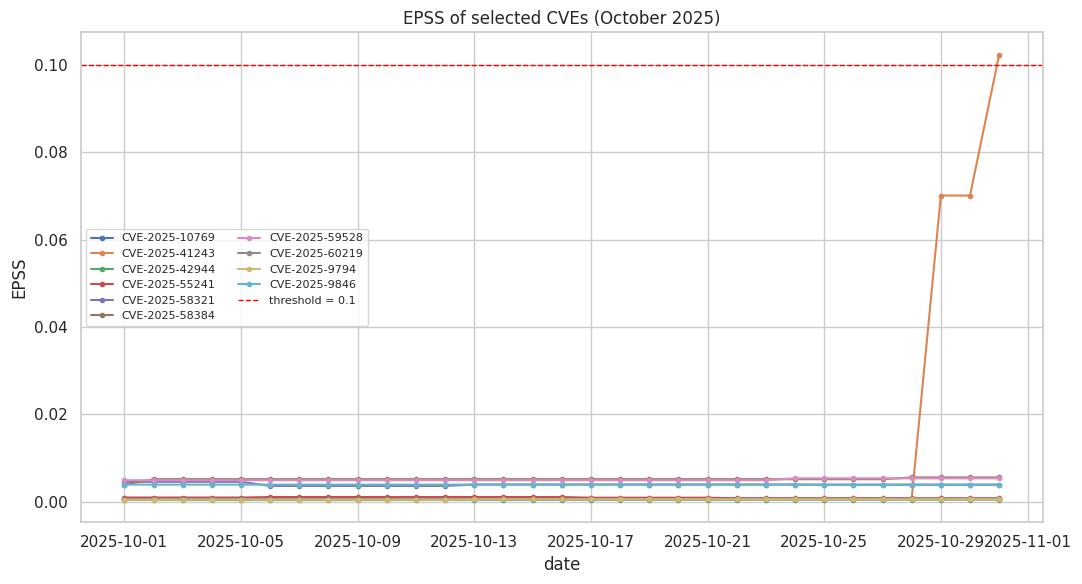

In [20]:
plt.figure(figsize=(11, 6))
for cve in epss_ts.columns:
    plt.plot(epss_ts.index, epss_ts[cve], marker='.', label=cve)
plt.axhline(0.1, color='red', ls='--', lw=1, label='threshold = 0.1')
plt.title("EPSS of selected CVEs (October 2025)")
plt.xlabel("date")
plt.ylabel("EPSS")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Most of the selected CVEs stayed close to their starting EPSS during October. One of them, **CVE-2025-41243** (Spring Cloud Gateway), rose clearly and reached about 0.10 by the end of the month, crossing the 0.1 threshold.

## Metrics

For each vulnerability I compute, relative to the reference date `t=0`:
- **mean daily gain** = sum over t=1..T of (epss at t − epss at 0), divided by T
- **max gain** = the largest increase from the starting EPSS over the window
- **days above 0.1** = number of days on which EPSS exceeded 0.1

and then aggregate over the 10 CVEs (mean of the mean daily gain, max of the max gain, sum of the days, and the number of vulnerabilities that went above 0.1 at least once).

In [21]:
epss_0 = epss_ts.iloc[0]           # EPSS at t=0
T = len(epss_ts) - 1               # number of days after t=0
gains = epss_ts.subtract(epss_0, axis=1)   # epss_{i,t} - epss_{i,0}
after = gains.iloc[1:]             # t = 1..T

metrics = pd.DataFrame({
    'epss_t0':          epss_0,
    'epss_tT':          epss_ts.iloc[-1],
    'mean_daily_gain':  after.sum() / T,
    'max_gain':         after.max(),
    'days_above_0.1':   (epss_ts.iloc[1:] > 0.1).sum(),
}).sort_values('max_gain', ascending=False)

print(metrics.round(5).to_string())

print("\nAggregated over the 10 CVEs:")
print(f"  mean daily gain (mean): {metrics['mean_daily_gain'].mean():.5f}")
print(f"  max gain (max):         {metrics['max_gain'].max():.5f}")
print(f"  days above 0.1 (sum):   {int(metrics['days_above_0.1'].sum())}")
print(f"  vulns above 0.1:        {int((metrics['days_above_0.1'] > 0).sum())} / 10")

                epss_t0  epss_tT  mean_daily_gain  max_gain  days_above_0.1
cve                                                                        
CVE-2025-41243  0.00063  0.10243          0.00805   0.10180               1
CVE-2025-58384  0.00390  0.00553          0.00128   0.00163               0
CVE-2025-59528  0.00489  0.00533          0.00012   0.00044               0
CVE-2025-60219  0.00043  0.00061          0.00014   0.00018               0
CVE-2025-55241  0.00093  0.00077         -0.00002   0.00011               0
CVE-2025-9794   0.00043  0.00053          0.00007   0.00010               0
CVE-2025-42944  0.00037  0.00047          0.00007   0.00010               0
CVE-2025-10769  0.00058  0.00057         -0.00004   0.00000               0
CVE-2025-58321  0.00454  0.00391         -0.00062   0.00000               0
CVE-2025-9846   0.00389  0.00379         -0.00002   0.00000               0

Aggregated over the 10 CVEs:
  mean daily gain (mean): 0.00090
  max gain (max):       

**Result.** Over October, **1 of the 10 selected CVEs (CVE-2025-41243) crossed the 0.1 threshold**, contributing essentially all of the aggregated gain; the other nine barely moved. So the "obvious targets" strategy produced one clear hit and a lot of vulnerabilities that stayed cold within this one-month window — which fits the earlier observation that EPSS only moves for the few CVEs that actually get an exploit or extra attention.

# Takeaways

- September 2025 had ~4.3k CVEs; ~96% already have a CVSS score.
- EPSS is heavily skewed towards zero, so almost all CVEs start below the 1% threshold.
- CVSS and current EPSS are not strongly related, so high-severity low-EPSS CVEs are the natural candidates.
- Selection: filter to low-EPSS, then keep the most severe, remotely and easily exploitable CVEs with commonly-exploited weakness types.
- Tracking (Oct 2025): only 1 of the 10 selected CVEs (CVE-2025-41243, Spring Cloud Gateway) rose above 0.1; the rest stayed low. Within a single month, EPSS moves for only a small number of CVEs, so picking severe, easily exploitable bugs gives some hits but most selections stay cold — a longer window would likely be needed to see more of them move.